In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from typing import Dict, Any
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import f1_score, confusion_matrix, roc_curve, auc, classification_report, make_scorer

In [2]:
raw_df = pd.read_csv('weatherAUS.csv')
raw_df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


In [3]:
def drop_na_values(df: pd.DataFrame, columns: list) -> pd.DataFrame:
    """
    Drop rows with NA values in the specified columns.
    """
    return df.dropna(subset=columns)


def split_data_by_year(df: pd.DataFrame, year_col: str) -> Dict[str, pd.DataFrame]:
    """
    Split the dataframe into training, validation, and test sets based on the year.
    """
    year = pd.to_datetime(df[year_col]).dt.year
    train_df = df[year < 2015]
    val_df = df[year == 2015]
    test_df = df[year > 2015]
    return {'train': train_df, 'val': val_df, 'test': test_df}


def create_inputs_targets(df_dict: Dict[str, pd.DataFrame], input_cols: list, target_col: str) -> Dict[str, Any]:
    """
    Create inputs and targets for training, validation, and test sets.
    """
    data = {}
    for split in df_dict:
        data[f'{split}_inputs'] = df_dict[split][input_cols].copy()
        data[f'{split}_targets'] = df_dict[split][target_col].copy()
    return data


def impute_missing_values(data: Dict[str, Any], numeric_cols: list):
    """
    Impute missing numerical values using the mean strategy.
    Returns the fitted imputer so it can be reused later (e.g. in Streamlit).
    """
    imputer = SimpleImputer(strategy='mean').fit(data['train_inputs'][numeric_cols])
    for split in ['train', 'val', 'test']:
        data[f'{split}_inputs'][numeric_cols] = imputer.transform(data[f'{split}_inputs'][numeric_cols])
    return imputer


def scale_numeric_features(data: Dict[str, Any], numeric_cols: list):
    """
    Scale numeric features using MinMaxScaler.
    Returns the fitted scaler so it can be reused later (e.g. in Streamlit).
    """
    scaler = MinMaxScaler().fit(data['train_inputs'][numeric_cols])
    for split in ['train', 'val', 'test']:
        data[f'{split}_inputs'][numeric_cols] = scaler.transform(data[f'{split}_inputs'][numeric_cols])
    return scaler


def encode_categorical_features(data: Dict[str, Any], categorical_cols: list):
    """
    One-hot encode categorical features.
    Returns the fitted encoder so it can be reused later (e.g. in Streamlit).
    """
    encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore').fit(data['train_inputs'][categorical_cols])
    encoded_cols = list(encoder.get_feature_names_out(categorical_cols))
    for split in ['train', 'val', 'test']:
        encoded = encoder.transform(data[f'{split}_inputs'][categorical_cols])
        data[f'{split}_inputs'] = pd.concat([data[f'{split}_inputs'], pd.DataFrame(encoded, columns=encoded_cols, index=data[f'{split}_inputs'].index)], axis=1)
        data[f'{split}_inputs'].drop(columns=categorical_cols, inplace=True)
    return encoder


def preprocess_data(raw_df: pd.DataFrame):
    """
    Preprocess the raw dataframe.

    Returns:
        data, imputer, scaler, encoder, numeric_cols, categorical_cols
    """
    raw_df = drop_na_values(raw_df, ['RainToday', 'RainTomorrow'])
    split_dfs = split_data_by_year(raw_df, 'Date')
    input_cols = list(raw_df.columns)[1:-1]
    target_col = 'RainTomorrow'
    data = create_inputs_targets(split_dfs, input_cols, target_col)

    numeric_cols = data['train_inputs'].select_dtypes(include=np.number).columns.tolist()
    categorical_cols = data['train_inputs'].select_dtypes('object').columns.tolist()

    imputer = impute_missing_values(data, numeric_cols)
    scaler = scale_numeric_features(data, numeric_cols)
    encoder = encode_categorical_features(data, categorical_cols)

    return data, imputer, scaler, encoder, numeric_cols, categorical_cols


def classify_analysis(targets, inputs, model, name=''):
    """
    Evaluates classification model performance.

    Includes:
    - F1 score
    - ROC AUC
    - Confusion matrix
    - ROC curve
    """

    classes = model.classes_
    pos_label = classes[1]  # клас, що відповідає стовпцю pred_proba[:, 1]

    pred_proba = model.predict_proba(inputs)[:, 1]
    pred_class = np.where(pred_proba >= 0.5, classes[1], classes[0])

    print(f'F1 score on {name}: {round(f1_score(targets, pred_class, pos_label=pos_label), 4)}')

    fpr, tpr, _ = roc_curve(targets, pred_proba, pos_label=pos_label)
    roc_auc = auc(fpr, tpr)

    print(f'AUC on {name}: {round(roc_auc, 4)}')
    print(classification_report(targets, pred_class))

    cf = confusion_matrix(targets, pred_class, normalize='true', labels=classes)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    sns.heatmap(cf, annot=True, ax=axes[0], xticklabels=classes, yticklabels=classes)
    axes[0].set_title("Confusion Matrix")
    axes[0].set_xlabel("Predicted")
    axes[0].set_ylabel("Actual")

    axes[1].plot(fpr, tpr)
    axes[1].plot([0, 1], [0, 1], linestyle='--')
    axes[1].set_title("ROC Curve")
    axes[1].set_xlabel("False Positive Rate")
    axes[1].set_ylabel("True Positive Rate")

    plt.show()

In [4]:
data, imputer, scaler, encoder, numeric_cols, categorical_cols = preprocess_data(raw_df)

X_train = data['train_inputs']
train_targets = data['train_targets']
X_val = data['val_inputs']
val_targets = data['val_targets']
X_test = data['test_inputs']
test_targets = data['test_targets']

In [5]:
rf_base = RandomForestClassifier(random_state = 42)
basic_rf_model = rf_base.fit(X_train, train_targets)

In [6]:
rf_base

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

F1 score on Training: 1.0
AUC on Training: 1.0
              precision    recall  f1-score   support

          No       1.00      1.00      1.00     76190
         Yes       1.00      1.00      1.00     21798

    accuracy                           1.00     97988
   macro avg       1.00      1.00      1.00     97988
weighted avg       1.00      1.00      1.00     97988



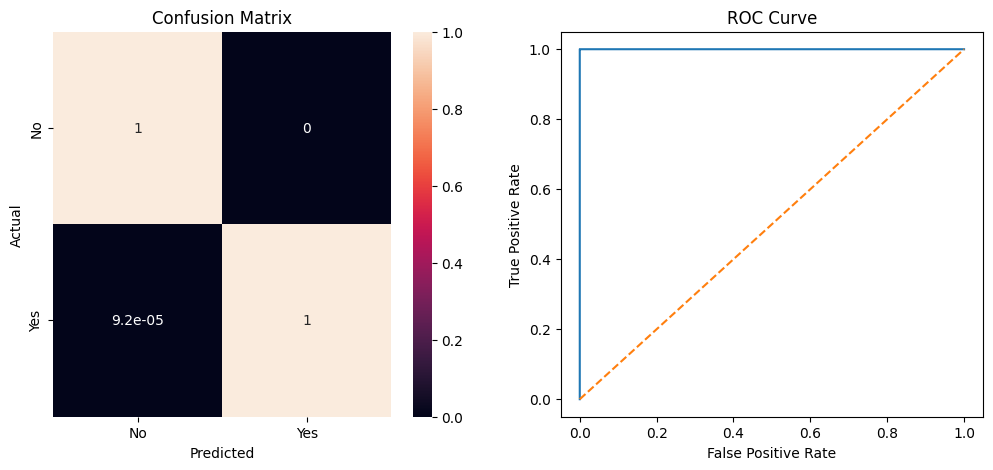

F1 score on Validation: 0.5681
AUC on Validation: 0.8786
              precision    recall  f1-score   support

          No       0.87      0.97      0.91     13511
         Yes       0.77      0.45      0.57      3578

    accuracy                           0.86     17089
   macro avg       0.82      0.71      0.74     17089
weighted avg       0.85      0.86      0.84     17089



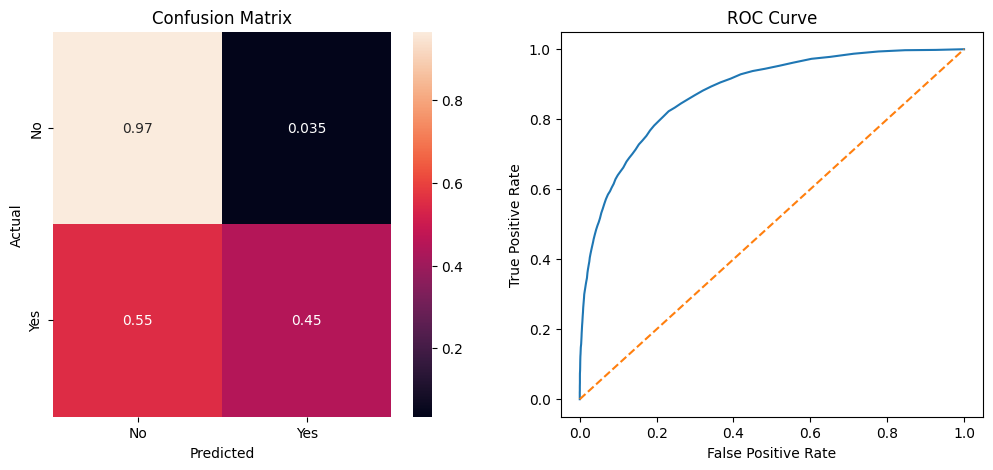

F1 score on Testing: 0.5855
AUC on Testing: 0.868
              precision    recall  f1-score   support

          No       0.86      0.95      0.90     19885
         Yes       0.74      0.48      0.59      5825

    accuracy                           0.85     25710
   macro avg       0.80      0.72      0.75     25710
weighted avg       0.84      0.85      0.83     25710



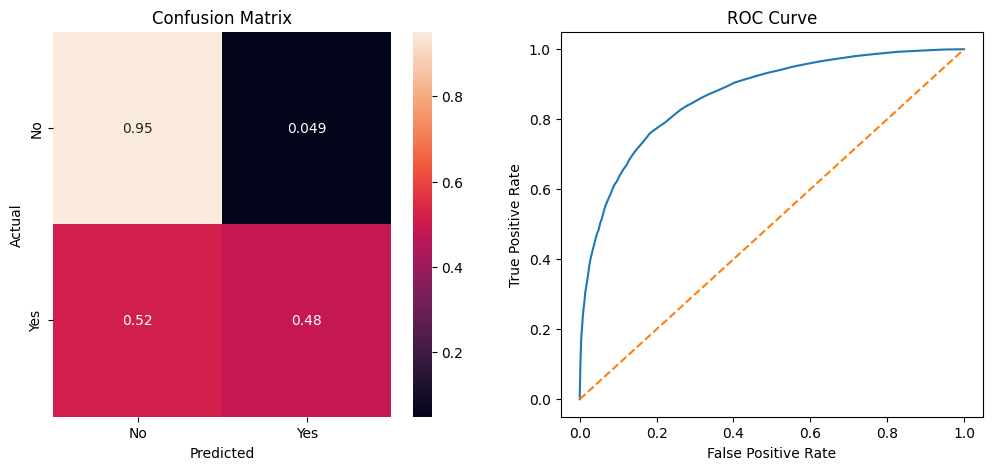

In [7]:
classify_analysis(train_targets, X_train, basic_rf_model, 'Training')
classify_analysis(val_targets, X_val, basic_rf_model, 'Validation')
classify_analysis(test_targets, X_test, basic_rf_model, 'Testing')

In [9]:
f1_yes_scorer = make_scorer(f1_score, pos_label='Yes')

random_param_rf = {
    'n_estimators': [25, 35, 45, 50, 100, 150, 200],
    'max_depth': [1, 2, 3, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None],
    'bootstrap': [True, False]
}

rf_random = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    random_param_rf,
    n_iter=50,
    scoring=f1_yes_scorer,
    cv=5,
    random_state=42,
    n_jobs=-1
)

In [10]:
rf_random = rf_random.fit(X_train, train_targets)
rf_random_model = rf_random.best_estimator_

In [11]:
print("Найкращі параметри:", rf_random.best_params_)
print("Найкращий CV F1:", round(rf_random.best_score_, 4))

Найкращі параметри: {'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': None, 'max_depth': 10, 'bootstrap': True}
Найкращий CV F1: 0.5631


F1 score on Training: 0.6657
AUC on Training: 0.9099
              precision    recall  f1-score   support

          No       0.88      0.97      0.92     76190
         Yes       0.83      0.55      0.67     21798

    accuracy                           0.88     97988
   macro avg       0.86      0.76      0.79     97988
weighted avg       0.87      0.88      0.87     97988



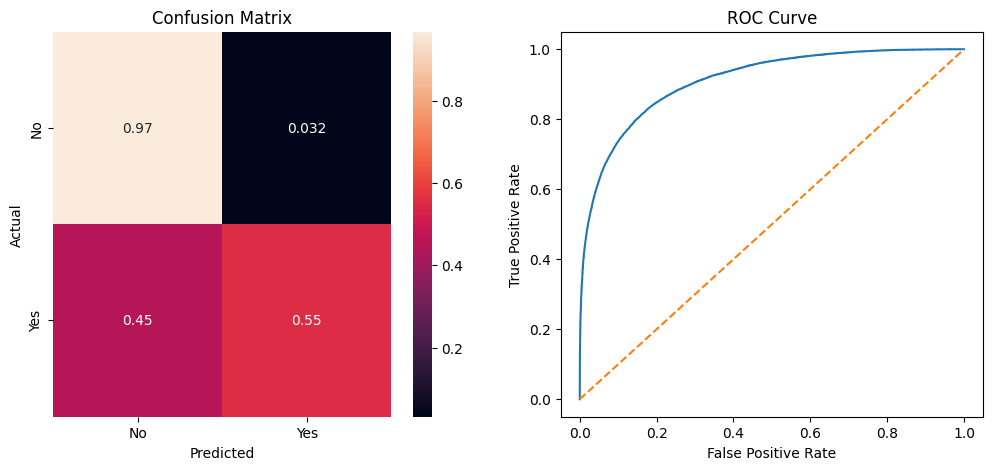

F1 score on Validation: 0.5586
AUC on Validation: 0.8695
              precision    recall  f1-score   support

          No       0.87      0.96      0.91     13511
         Yes       0.76      0.44      0.56      3578

    accuracy                           0.85     17089
   macro avg       0.81      0.70      0.74     17089
weighted avg       0.84      0.85      0.84     17089



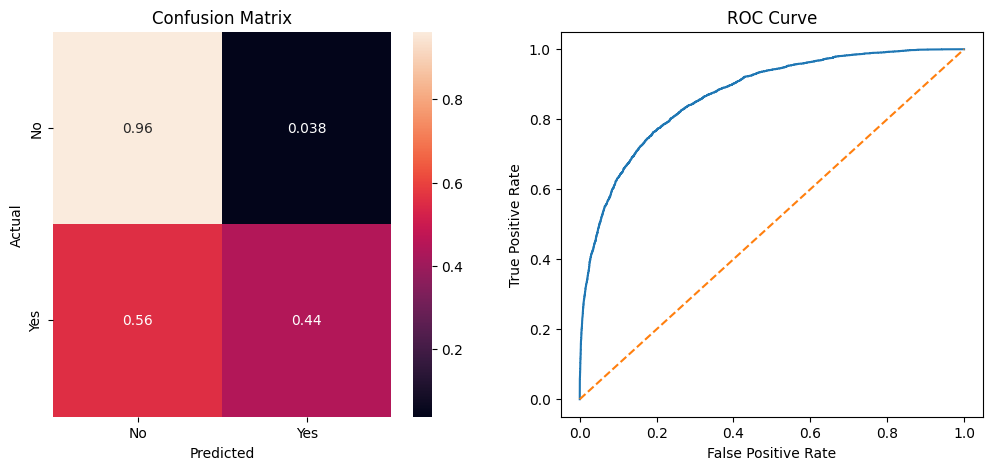

F1 score on Testing: 0.577
AUC on Testing: 0.8609
              precision    recall  f1-score   support

          No       0.86      0.95      0.90     19885
         Yes       0.74      0.47      0.58      5825

    accuracy                           0.84     25710
   macro avg       0.80      0.71      0.74     25710
weighted avg       0.83      0.84      0.83     25710



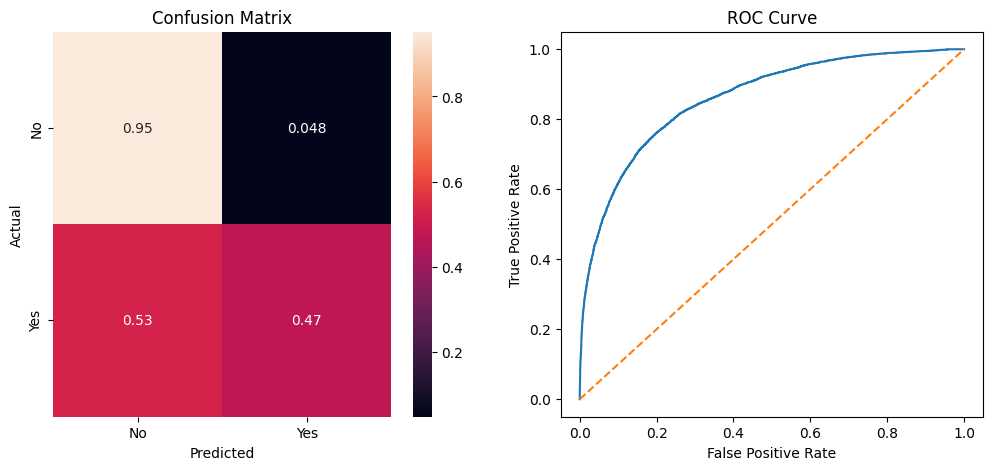

In [12]:
classify_analysis(train_targets, X_train, rf_random_model, 'Training')
classify_analysis(val_targets, X_val, rf_random_model, 'Validation')
classify_analysis(test_targets, X_test, rf_random_model, 'Testing')

In [13]:
import os

final_model = rf_random_model

aussie_rain = {
    'model': final_model,
    'imputer': imputer,
    'scaler': scaler,
    'encoder': encoder,
    'input_cols': X_train.columns.tolist(),
    'target_col': 'RainTomorrow',
    'classes': final_model.classes_.tolist(),
    'numeric_cols': numeric_cols,
    'categorical_cols': categorical_cols,
}

os.makedirs('models', exist_ok=True)
joblib.dump(aussie_rain, 'models/rf_model.joblib')

['models/rf_model.joblib']

In [14]:
aussie_rain2 = joblib.load('models/rf_model.joblib')
aussie_rain2.keys()

dict_keys(['model', 'imputer', 'scaler', 'encoder', 'input_cols', 'target_col', 'classes', 'numeric_cols', 'categorical_cols'])